In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models 
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from keras.utils import plot_model

#load data
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [44]:
print("x_train shape:", X_train.shape)
print("y_train shape:", Y_train.shape)
print("x_test shape:", X_test.shape)
print("y_test shape:", Y_test.shape)
#visualizing data

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [45]:
#preparing data
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)


# as the values of the pixels go from 0 to 255, we will normalize the data by dividing by 255. This will make the values of the pixels go from 0 to 1, which will help the model to learn better.

#one-hot encoding the labels
train_labels = to_categorical(Y_train, 10)
test_labels = to_categorical(Y_test, 10)

In [46]:
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(500, activation='relu'),
    layers.Dense(250, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [47]:
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,260 (1.98 MB)

 Trainable params: 520,260 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [53]:
#training the model
history = model.fit(X_train, train_labels, epochs=10, batch_size=64, validation_split=0.2)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9945 - loss: 0.0184 - val_accuracy: 0.9858 - val_loss: 0.0754
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9971 - loss: 0.0097 - val_accuracy: 0.9885 - val_loss: 0.0635
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9961 - loss: 0.0116 - val_accuracy: 0.9878 - val_loss: 0.0641
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9974 - loss: 0.0083 - val_accuracy: 0.9847 - val_loss: 0.0808
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9961 - loss: 0.0137 - val_accuracy: 0.9860 - val_loss: 0.0723
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9974 - loss: 0.0083 - val_accuracy: 0.9869 - val_loss: 0.0678
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9977 - loss: 0.0069 - val_accuracy: 0.9848 - val_loss: 0.0795
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9971 - loss: 0.0101 - val_accuracy: 0.

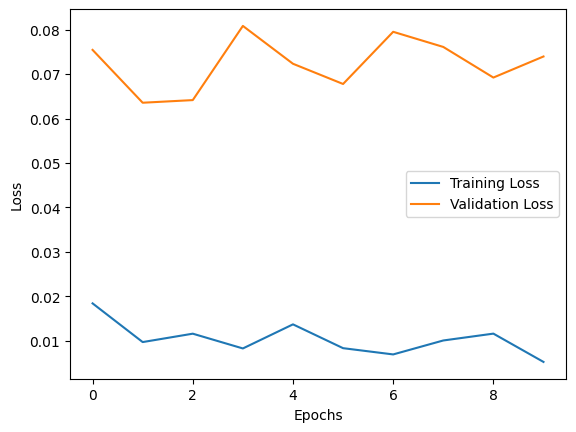

In [54]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [55]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9805999994277954


In [56]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


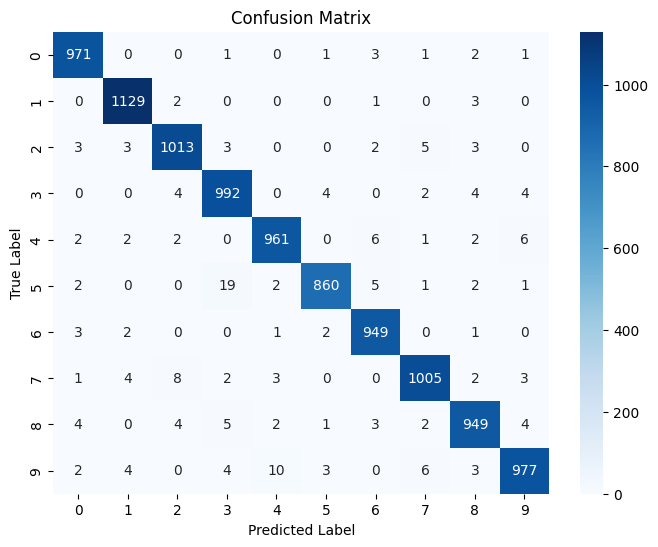

In [59]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()